Imports

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Paths

In [12]:
BASE           = Path("../../")
METRICS        = BASE / "models" / "metrics"
DASHBOARD_DATA = BASE / "dashboard" / "data"
DASHBOARD_DATA.mkdir(parents=True, exist_ok=True)
print("Metrics dir:",       METRICS)
print("Dashboard data dir:", DASHBOARD_DATA)

Metrics dir: ..\..\models\metrics
Dashboard data dir: ..\..\dashboard\data


Cargar métricas

In [13]:
def read_csv(path):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    print("⚠️ Archivo no encontrado:", p)
    return None

files = {
    "BASELINE":    METRICS / "baseline_comparison.csv",
    "ARIMA":       METRICS / "arima_results.csv",
    "SARIMA":      METRICS / "sarima_results.csv",
    "SARIMAX":     METRICS / "sarimax_results.csv",
    "RANDOMFOREST":METRICS / "random_forest_results.csv",
    "XGBOOST":     METRICS / "xgb_results.csv",
}

dfs = []
for model_name, path in files.items():
    df = read_csv(path)
    if df is not None:
        df["model"] = model_name
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all.columns = df_all.columns.str.lower()
df_all

,hotel,modelo,mae,rmse,mape,model,order,seasonal_order
0,HOTEL_1,Moving Average (7),0.084328,0.104462,21.059776,BASELINE,NaN,NaN
1,HOTEL_1,Naive,0.084691,0.111689,20.196404,BASELINE,NaN,NaN
2,HOTEL_1,Seasonal Naive,0.130254,0.164885,32.355773,BASELINE,NaN,NaN
3,HOTEL_2,Naive,0.029492,0.041009,4.721934,BASELINE,NaN,NaN
4,HOTEL_2,Moving Average (7),0.035742,0.051604,6.011531,BASELINE,NaN,NaN
5,HOTEL_2,Seasonal Naive,0.065529,0.094092,11.130254,BASELINE,NaN,NaN
6,HOTEL_3,Naive,0.020508,0.026387,3.434707,BASELINE,NaN,NaN
7,HOTEL_3,Moving Average (7),0.026097,0.033197,4.518617,BASELINE,NaN,NaN
8,HOTEL_3,Seasonal Naive,0.048084,0.063099,8.243730,BASELINE,NaN,NaN
9,HOTEL_1,ARIMA,0.118347,0.143329,30.029578,ARIMA,NaN,NaN


Asegurar columnas estándar

In [14]:
df_all = df_all[["hotel", "model", "mae", "rmse", "mape"]].copy()
df_all["hotel"] = df_all["hotel"].astype(str)
df_all.sort_values(["hotel", "mae"])

,hotel,model,mae,rmse,mape
21,HOTEL_1,XGBOOST,0.052480,0.103318,9.551614
18,HOTEL_1,RANDOMFOREST,0.069182,0.119837,13.111639
0,HOTEL_1,BASELINE,0.084328,0.104462,21.059776
1,HOTEL_1,BASELINE,0.084691,0.111689,20.196404
15,HOTEL_1,SARIMAX,0.088223,0.115243,19.938561
9,HOTEL_1,ARIMA,0.118347,0.143329,30.029578
12,HOTEL_1,SARIMA,0.122953,0.147184,28.319673
2,HOTEL_1,BASELINE,0.130254,0.164885,32.355773
3,HOTEL_2,BASELINE,0.029492,0.041009,4.721934
4,HOTEL_2,BASELINE,0.035742,0.051604,6.011531


Mejor baseline por hotel

In [15]:
baseline_df  = df_all[df_all["model"] == "BASELINE"]
best_baseline = (
    baseline_df.sort_values(["hotel", "mae"])
               .groupby("hotel")
               .first()
               .reset_index()[["hotel", "mae"]]
               .rename(columns={"mae": "baseline_mae"})
)
best_baseline

,hotel,baseline_mae
0,HOTEL_1,0.084328
1,HOTEL_2,0.029492
2,HOTEL_3,0.020508


Comparar cada modelo con su baseline (Δ absoluto y %)

In [16]:
df_cmp = df_all.merge(best_baseline, on="hotel", how="left")
df_cmp["delta_mae"] = df_cmp["mae"] - df_cmp["baseline_mae"]
df_cmp["delta_pct"] = (df_cmp["delta_mae"] / df_cmp["baseline_mae"]) * 100
df_cmp.sort_values(["hotel", "mae"])

,hotel,model,mae,rmse,mape,baseline_mae,delta_mae,delta_pct
21,HOTEL_1,XGBOOST,0.052480,0.103318,9.551614,0.084328,-0.031848,-37.767054
18,HOTEL_1,RANDOMFOREST,0.069182,0.119837,13.111639,0.084328,-0.015146,-17.961244
0,HOTEL_1,BASELINE,0.084328,0.104462,21.059776,0.084328,0.000000,0.000000
1,HOTEL_1,BASELINE,0.084691,0.111689,20.196404,0.084328,0.000363,0.430769
15,HOTEL_1,SARIMAX,0.088223,0.115243,19.938561,0.084328,0.003895,4.619287
9,HOTEL_1,ARIMA,0.118347,0.143329,30.029578,0.084328,0.034019,40.340869
12,HOTEL_1,SARIMA,0.122953,0.147184,28.319673,0.084328,0.038625,45.803522
2,HOTEL_1,BASELINE,0.130254,0.164885,32.355773,0.084328,0.045926,54.461538
3,HOTEL_2,BASELINE,0.029492,0.041009,4.721934,0.029492,0.000000,0.000000
4,HOTEL_2,BASELINE,0.035742,0.051604,6.011531,0.029492,0.006250,21.192678


Ranking por hotel

In [17]:
df_cmp["rank"] = df_cmp.groupby("hotel")["mae"].rank(method="first")
df_cmp.sort_values(["hotel", "rank"])

,hotel,model,mae,rmse,mape,baseline_mae,delta_mae,delta_pct,rank
21,HOTEL_1,XGBOOST,0.052480,0.103318,9.551614,0.084328,-0.031848,-37.767054,1.0
18,HOTEL_1,RANDOMFOREST,0.069182,0.119837,13.111639,0.084328,-0.015146,-17.961244,2.0
0,HOTEL_1,BASELINE,0.084328,0.104462,21.059776,0.084328,0.000000,0.000000,3.0
1,HOTEL_1,BASELINE,0.084691,0.111689,20.196404,0.084328,0.000363,0.430769,4.0
15,HOTEL_1,SARIMAX,0.088223,0.115243,19.938561,0.084328,0.003895,4.619287,5.0
9,HOTEL_1,ARIMA,0.118347,0.143329,30.029578,0.084328,0.034019,40.340869,6.0
12,HOTEL_1,SARIMA,0.122953,0.147184,28.319673,0.084328,0.038625,45.803522,7.0
2,HOTEL_1,BASELINE,0.130254,0.164885,32.355773,0.084328,0.045926,54.461538,8.0
3,HOTEL_2,BASELINE,0.029492,0.041009,4.721934,0.029492,0.000000,0.000000,1.0
4,HOTEL_2,BASELINE,0.035742,0.051604,6.011531,0.029492,0.006250,21.192678,2.0


Seleccionar el mejor modelo REAL (excluyendo baseline)

In [18]:
df_no_baseline = df_cmp[df_cmp["model"] != "BASELINE"]
best_models = (
    df_no_baseline.sort_values(["hotel", "mae"])
                  .groupby("hotel")
                  .first()
                  .reset_index()
)
best_models

,hotel,model,mae,rmse,mape,baseline_mae,delta_mae,delta_pct,rank
0,HOTEL_1,XGBOOST,0.052480,0.103318,9.551614,0.084328,-0.031848,-37.767054,1.0
1,HOTEL_2,XGBOOST,0.043035,0.055046,6.189086,0.029492,0.013543,45.920443,3.0
2,HOTEL_3,XGBOOST,0.035688,0.041940,5.939267,0.020508,0.015180,74.018979,3.0


Guardar datasets procesados para el dashboard

In [19]:
df_cmp.to_parquet(DASHBOARD_DATA / "model_comparison.parquet", index=False)
best_models.to_parquet(DASHBOARD_DATA / "best_models.parquet",  index=False)
print("✅ Datasets guardados en:")
print("  ", DASHBOARD_DATA / "model_comparison.parquet")
print("  ", DASHBOARD_DATA / "best_models.parquet")

✅ Datasets guardados en:
   ..\..\dashboard\data\model_comparison.parquet
   ..\..\dashboard\data\best_models.parquet


Visualización comparativa

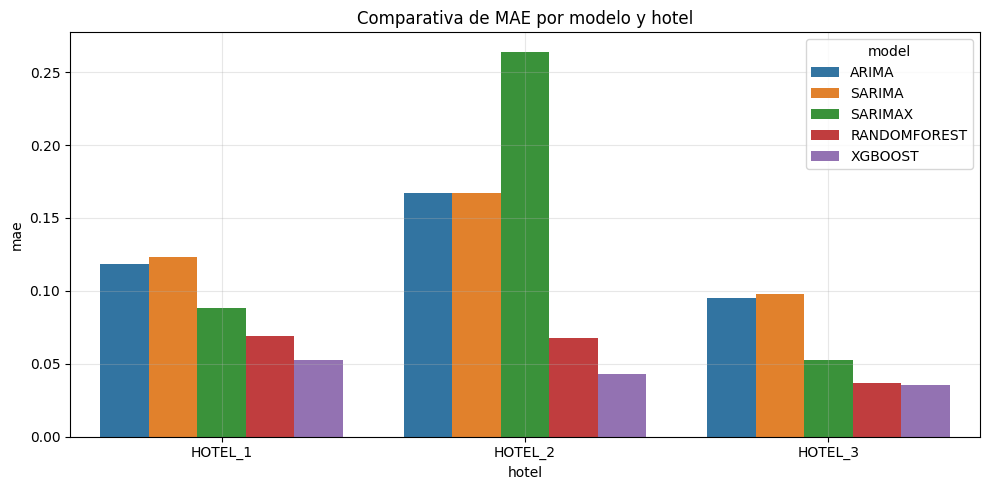

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_cmp[df_cmp["model"] != "BASELINE"],
    x="hotel", y="mae", hue="model"
)
plt.title("Comparativa de MAE por modelo y hotel")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()